# PhysioNet EEG Motor Movement/Imagery — Exploration

This notebook explores subject 2 from the PhysioNet EEG Motor Movement/Imagery dataset.

It has two parts:
1. **Alpha rhythm** — comparing eyes-open vs eyes-closed baseline runs (the EEG "hello world").
2. **Motor imagery** — loading the imagined left/right hand runs and epoching them into labeled trials.

Run top-to-bottom from a fresh kernel.

In [2]:
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import mne
from mne.datasets import eegbci
from pathlib import Path

print('MNE version:', mne.__version__)

MNE version: 1.12.1


In [3]:
# Where the dataset lives, and which subject we analyze
data_dir = Path.home() / "projects" / "bci" / "data" / "raw"
data_dir.mkdir(parents=True, exist_ok=True)
subject = 2

# Standard montage (electrode 3D positions) reused throughout the notebook
montage = mne.channels.make_standard_montage("standard_1005")
print("Subject:", subject)
print("Data dir:", data_dir)

Subject: 2
Data dir: /home/beecki303/projects/bci/data/raw


## 2. Alpha rhythm: eyes-open (run 1) vs eyes-closed (run 2)

Baseline runs 1 and 2 are resting recordings. With eyes **closed**, a strong ~10 Hz alpha rhythm appears over the occipital cortex. We load both runs and compare their power spectra at O1/O2/Oz.

In [4]:
# Download + load the two baseline runs (1 = eyes open, 2 = eyes closed)
baseline_runs = [1, 2]
baseline_fnames = eegbci.load_data(subjects=[subject], runs=baseline_runs, path=str(data_dir))

# Eyes OPEN = run 1
raw_eyes_open = mne.io.read_raw_edf(baseline_fnames[0], preload=True)
eegbci.standardize(raw_eyes_open)
raw_eyes_open.set_montage(montage)

# Eyes CLOSED = run 2
raw_eyes_closed = mne.io.read_raw_edf(baseline_fnames[1], preload=True)
eegbci.standardize(raw_eyes_closed)
raw_eyes_closed.set_montage(montage)

print("Eyes open duration:", round(raw_eyes_open.times[-1], 1), "s")
print("Eyes closed duration:", round(raw_eyes_closed.times[-1], 1), "s")

Extracting EDF parameters from /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Extracting EDF parameters from /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R02.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Eyes open duration: 61.0 s
Eyes closed duration: 61.0 s


Using matplotlib as 2D backend.


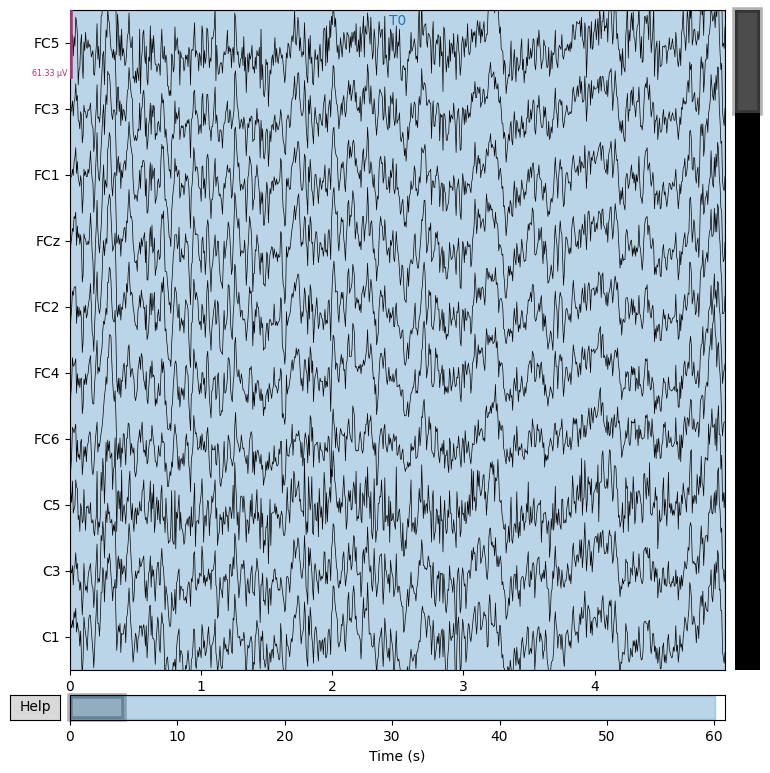

In [5]:
# Quick look at raw eyes-open EEG (first 5 seconds, 10 channels)
%matplotlib inline
raw_eyes_open.plot(duration=5, n_channels=10, scalings="auto", show=True);

Effective window size : 12.800 (s)
Effective window size : 12.800 (s)


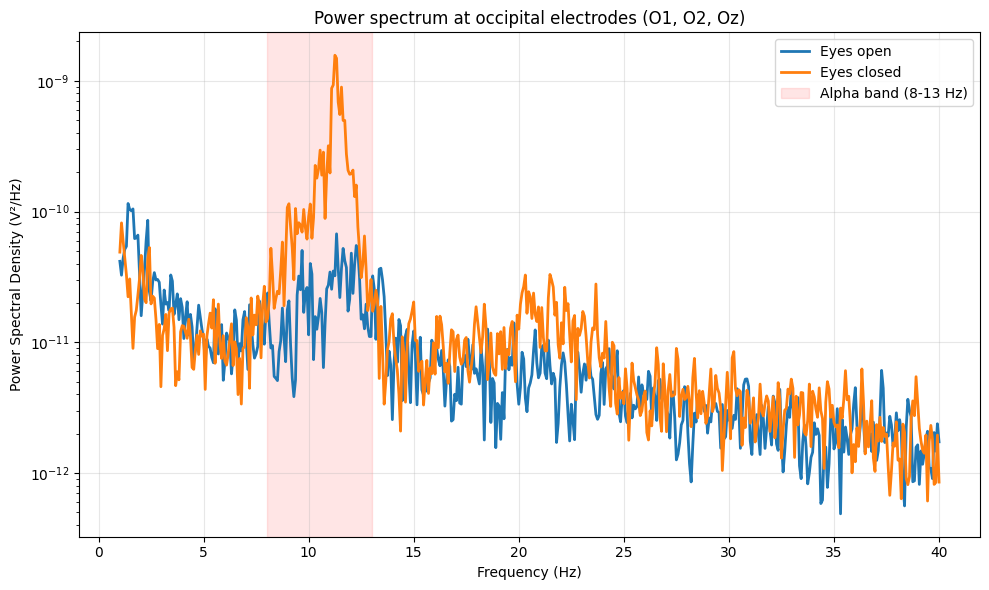

In [6]:
# Compare power spectra at occipital channels: alpha should spike when eyes are closed
occipital_channels = ["O1", "O2", "Oz"]

fig, ax = plt.subplots(figsize=(10, 6))

psd_open = raw_eyes_open.compute_psd(fmin=1, fmax=40, picks=occipital_channels)
psd_closed = raw_eyes_closed.compute_psd(fmin=1, fmax=40, picks=occipital_channels)

freqs = psd_open.freqs
power_open = psd_open.get_data().mean(axis=0)
power_closed = psd_closed.get_data().mean(axis=0)

ax.semilogy(freqs, power_open, label="Eyes open", linewidth=2)
ax.semilogy(freqs, power_closed, label="Eyes closed", linewidth=2)
ax.axvspan(8, 13, alpha=0.1, color="red", label="Alpha band (8-13 Hz)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density (V²/Hz)")
ax.set_title("Power spectrum at occipital electrodes (O1, O2, Oz)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Motor imagery: runs 4, 8, 12 (imagined left vs right fist)

These three runs are the "imagine left vs right fist" task. Annotations mark each cue:
- **T0** = rest
- **T1** = imagined **left** fist
- **T2** = imagined **right** fist

We load and concatenate the three runs, clean them, and extract the events.

In [7]:
# E7: Load + concatenate the three motor imagery runs
imagery_runs = [4, 8, 12]
imagery_fnames = eegbci.load_data(subjects=[subject], runs=imagery_runs, path=str(data_dir))

raws = [mne.io.read_raw_edf(f, preload=True) for f in imagery_fnames]
raw_mi = mne.concatenate_raws(raws)

eegbci.standardize(raw_mi)
raw_mi.set_montage(montage)

events, event_id = mne.events_from_annotations(raw_mi)

print("Event ID mapping:", event_id)
print("Total number of events:", len(events))
print(f"Duration: {raw_mi.times[-1]:.1f} seconds (expect ~369)")
print(f"First 10 channels: {raw_mi.ch_names[:10]}")

Extracting EDF parameters from /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /home/beecki303/projects/bci/data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0/S002/S002R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Event ID mapping: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Total number of events: 90
Duration: 369.0 seconds (expect ~369)
First 10 channels: ['FC5', 'FC3', 'FC1', 'FC

In [8]:
# E8: Epoch into labeled left/right trials
# T1 = imagined LEFT fist, T2 = imagined RIGHT fist
epoch_event_id = {"T1": event_id["T1"], "T2": event_id["T2"]}

# Window 0.5s-2.5s after each cue: skip the cue-reaction transient,
# capture the strongest motor-imagery period
tmin, tmax = 0.5, 2.5

epochs = mne.Epochs(
    raw_mi, events,
    event_id=epoch_event_id,
    tmin=tmin, tmax=tmax,
    baseline=None,
    picks="eeg",
    preload=True,
)

print(epochs)
print("\nData shape (trials, channels, samples):", epochs.get_data().shape)

Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 45 events and 321 original time points ...
0 bad epochs dropped
<Epochs | 45 events (all good), 0.5 – 2.5 s (baseline off), ~7.1 MiB, data loaded,
 'T1': 23
 'T2': 22>

Data shape (trials, channels, samples): (45, 64, 321)


    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


Mean mu-band power (averaged over trials):
  C3:  LEFT imagery = 1.72e-09,  RIGHT imagery = 1.46e-09
  C4:  LEFT imagery = 1.07e-09,  RIGHT imagery = 1.31e-09


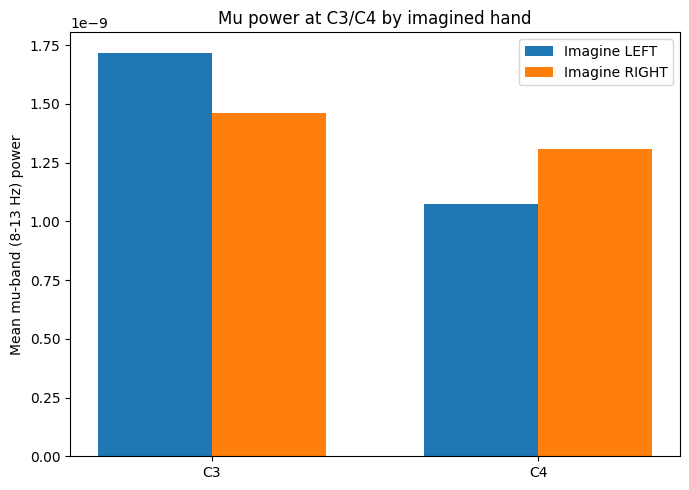

In [9]:
# E9: Compare mu-band (8-13 Hz) power at C3 and C4 for left vs right imagery
# T1 = imagined LEFT fist, T2 = imagined RIGHT fist

# Split epochs by condition
epochs_left = epochs['T1']
epochs_right = epochs['T2']

# Compute power spectral density for each condition, focused on the mu band
psd_left = epochs_left.compute_psd(fmin=8, fmax=13, picks=['C3', 'C4'])
psd_right = epochs_right.compute_psd(fmin=8, fmax=13, picks=['C3', 'C4'])

# Average power across the mu band and across trials -> one number per channel per condition
# shape of get_data(): (n_trials, n_channels, n_freqs)
left_power = psd_left.get_data().mean(axis=(0, 2))   # average over trials and freqs
right_power = psd_right.get_data().mean(axis=(0, 2))

ch_names = ['C3', 'C4']
print("Mean mu-band power (averaged over trials):")
for i, ch in enumerate(ch_names):
    print(f"  {ch}:  LEFT imagery = {left_power[i]:.2e},  RIGHT imagery = {right_power[i]:.2e}")

# Quick bar chart
import numpy as np
x = np.arange(len(ch_names))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, left_power, width, label='Imagine LEFT')
ax.bar(x + width/2, right_power, width, label='Imagine RIGHT')
ax.set_xticks(x); ax.set_xticklabels(ch_names)
ax.set_ylabel('Mean mu-band (8-13 Hz) power')
ax.set_title('Mu power at C3/C4 by imagined hand')
ax.legend()
plt.tight_layout()
plt.show()

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


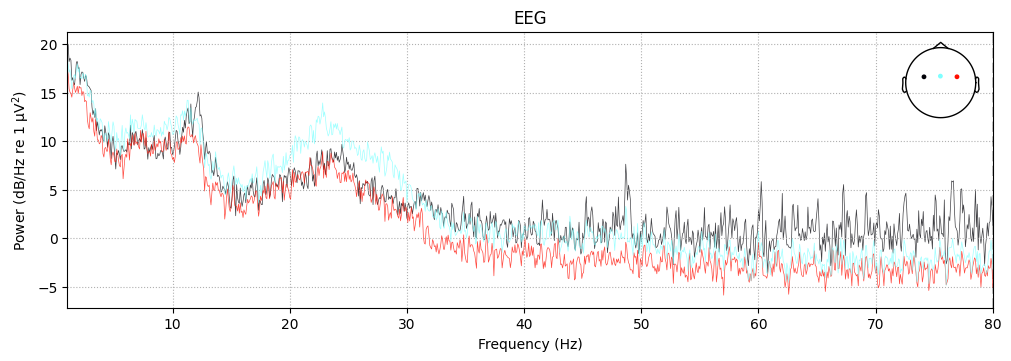

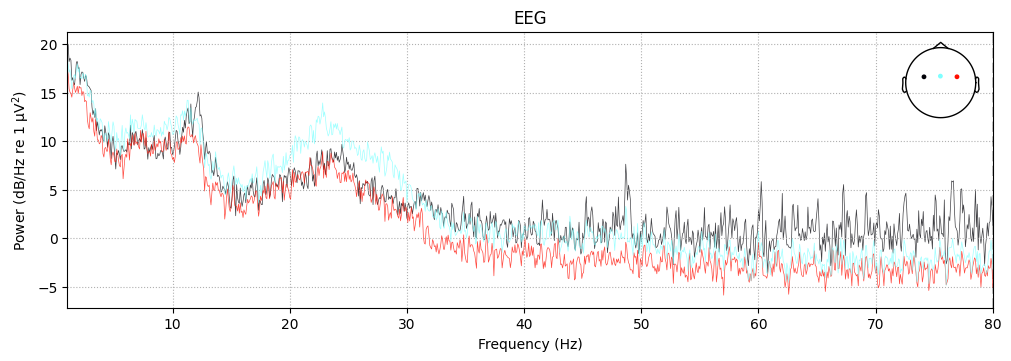

In [10]:
# Step 0: Look at the full power spectrum of the raw (unfiltered) motor imagery data
# Plot across a wide range (1-80 Hz) to see drift, brain bands, and any 60 Hz mains spike

# Average the spectrum across the motor channels we care about
motor_channels = ['C3', 'Cz', 'C4']

raw_psd = raw_mi.compute_psd(fmin=1, fmax=80, picks=motor_channels)
raw_psd.plot(picks=motor_channels,average= False)

Effective window size : 12.800 (s)


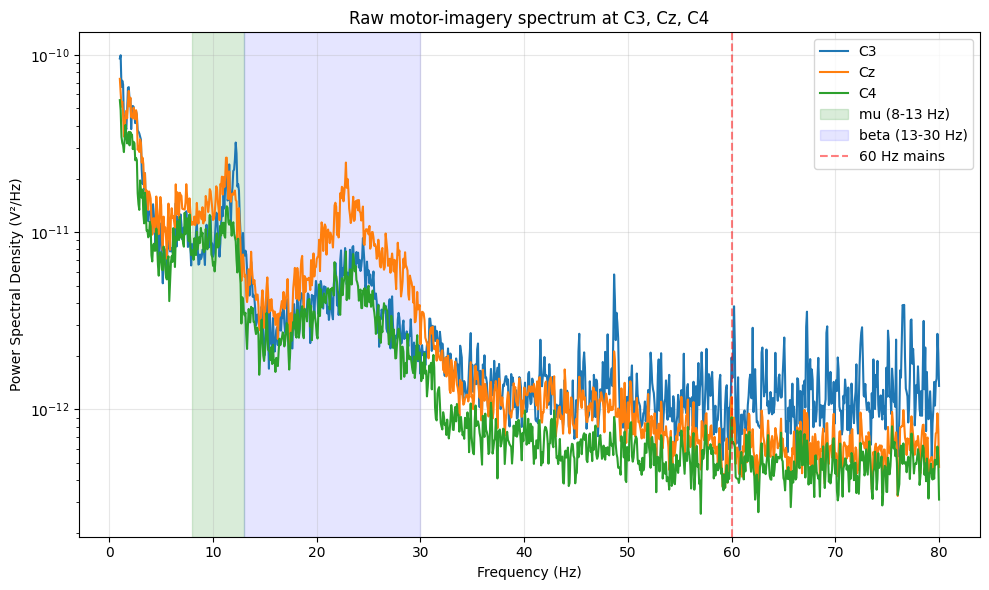

In [11]:
motor_channels = ['C3', 'Cz', 'C4']
raw_psd = raw_mi.compute_psd(fmin=1, fmax=80, picks=motor_channels)

freqs = raw_psd.freqs
powers = raw_psd.get_data()  # shape: (n_channels, n_frequencies)

fig, ax = plt.subplots(figsize=(10, 6))
for i, ch in enumerate(motor_channels):
    ax.semilogy(freqs, powers[i], label=ch, linewidth=1.5)
ax.axvspan(8, 13, alpha=0.15, color='green', label='mu (8-13 Hz)')
ax.axvspan(13, 30, alpha=0.10, color='blue', label='beta (13-30 Hz)')
ax.axvline(60, color='red', linestyle='--', alpha=0.5, label='60 Hz mains')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density (V²/Hz)')
ax.set_title('Raw motor-imagery spectrum at C3, Cz, C4')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Filtering raw data in 3 contiguous segments
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1057 samples (6.606 s)

Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth

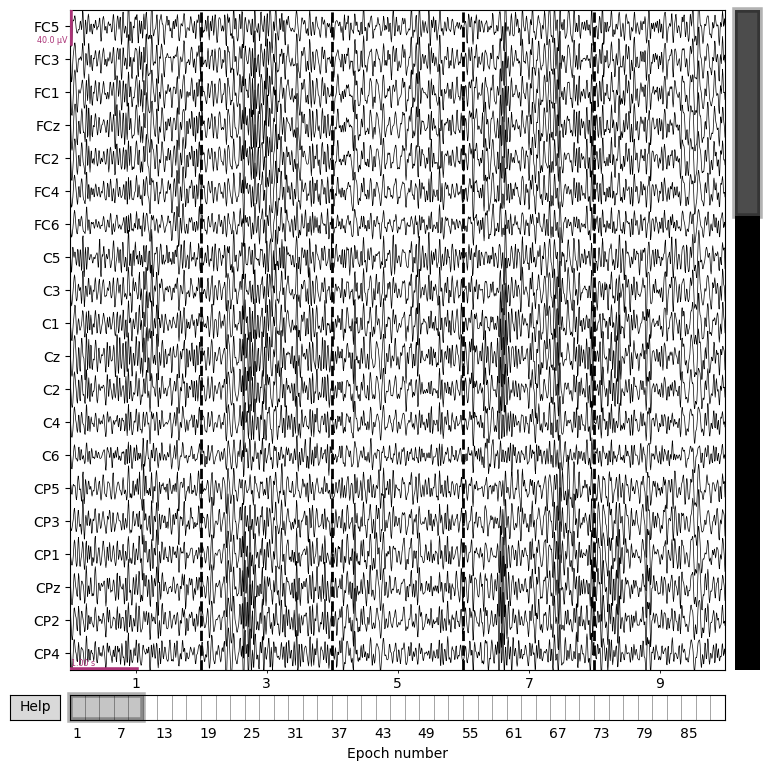

<Epochs | 45 events (all good), 0.5 – 2.5 s (baseline off), ~7.1 MiB, data loaded,
 'T1': 23
 'T2': 22>
Filtered epochs shape: (45, 64, 321)


In [12]:
# FILTERING: apply notch + bandpass to the continuous data, then re-epoch
# Work on a COPY so the original unfiltered raw_mi stays intact for comparison
raw_filtered = raw_mi.copy()

# 1) Notch filter at 60 Hz — removes US mains hum (precautionary on this clean dataset)
raw_filtered.notch_filter(freqs=60.0, picks='eeg')

# 2) Bandpass 8–30 Hz — keeps mu + beta, removes drift below and noise above
raw_filtered.filter(l_freq=8.0, h_freq=30.0, picks='eeg')

# Re-epoch from the FILTERED continuous data, using the same windows as before
epochs_filt = mne.Epochs(
    raw_filtered, events,
    event_id=epoch_event_id,
    tmin=tmin, tmax=tmax,
    baseline=None, picks='eeg', preload=True,
)

epochs_filt.plot(n_epochs=5)  # drop any epochs with extreme values (none expected here)
print(epochs_filt)
print("Filtered epochs shape:", epochs_filt.get_data().shape)

Effective window size : 12.800 (s)
Effective window size : 12.800 (s)


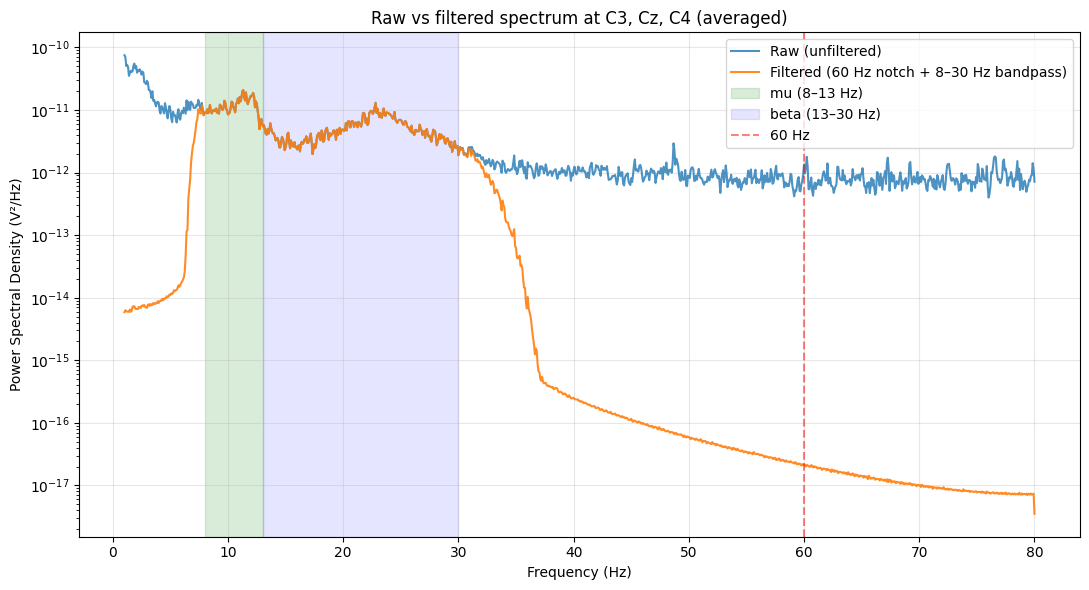

In [13]:
# Compare RAW vs FILTERED spectrum at the motor channels
motor_channels = ['C3', 'Cz', 'C4']

psd_raw = raw_mi.compute_psd(fmin=1, fmax=80, picks=motor_channels)
psd_filt = raw_filtered.compute_psd(fmin=1, fmax=80, picks=motor_channels)

freqs = psd_raw.freqs
raw_power = psd_raw.get_data().mean(axis=0)    # average the 3 channels
filt_power = psd_filt.get_data().mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 6))
ax.semilogy(freqs, raw_power, label='Raw (unfiltered)', linewidth=1.5, alpha=0.8)
ax.semilogy(freqs, filt_power, label='Filtered (60 Hz notch + 8–30 Hz bandpass)',
            linewidth=1.5, alpha=0.9)
ax.axvspan(8, 13, alpha=0.15, color='green', label='mu (8–13 Hz)')
ax.axvspan(13, 30, alpha=0.10, color='blue', label='beta (13–30 Hz)')
ax.axvline(60, color='red', linestyle='--', alpha=0.5, label='60 Hz')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density (V²/Hz)')
ax.set_title('Raw vs filtered spectrum at C3, Cz, C4 (averaged)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
Filtered mu-band power (averaged over trials):
  C3:  LEFT = 1.67e-09,  RIGHT = 1.42e-09
  C4:  LEFT = 1.03e-09,  RIGHT = 1.27e-09


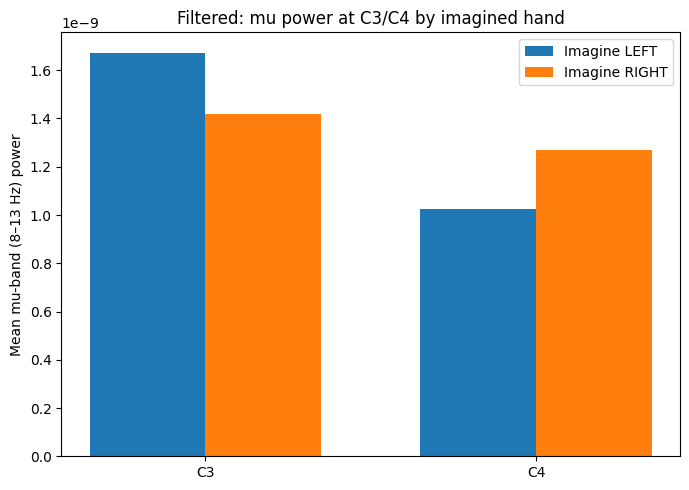

In [14]:
# Re-run the C3/C4 mu comparison on FILTERED epochs
epochs_left_f = epochs_filt['T1']    # imagined LEFT
epochs_right_f = epochs_filt['T2']   # imagined RIGHT

psd_left_f = epochs_left_f.compute_psd(fmin=8, fmax=13, picks=['C3', 'C4'])
psd_right_f = epochs_right_f.compute_psd(fmin=8, fmax=13, picks=['C3', 'C4'])

left_power_f = psd_left_f.get_data().mean(axis=(0, 2))
right_power_f = psd_right_f.get_data().mean(axis=(0, 2))

ch_names = ['C3', 'C4']
print("Filtered mu-band power (averaged over trials):")
for i, ch in enumerate(ch_names):
    print(f"  {ch}:  LEFT = {left_power_f[i]:.2e},  RIGHT = {right_power_f[i]:.2e}")

x = np.arange(len(ch_names)); width = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, left_power_f, width, label='Imagine LEFT')
ax.bar(x + width/2, right_power_f, width, label='Imagine RIGHT')
ax.set_xticks(x); ax.set_xticklabels(ch_names)
ax.set_ylabel('Mean mu-band (8–13 Hz) power')
ax.set_title('Filtered: mu power at C3/C4 by imagined hand')
ax.legend()
plt.tight_layout()
plt.show()

Applying baseline correction (mode: logratio)


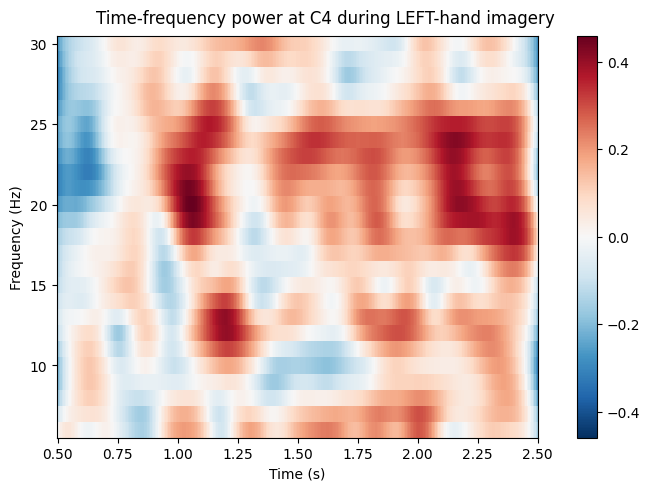

[<Figure size 640x480 with 2 Axes>]

In [15]:
# E10: Time-frequency plot showing ERD/ERS over the trial
# Use the broadband `epochs` (NOT the narrowband epochs_filt) so the TFR is informative

from mne.time_frequency import tfr_morlet

# Frequencies to analyze: 6-30 Hz covers mu and beta
freqs_tfr = np.arange(6, 31, 1)        # 6,7,...,30 Hz
n_cycles = freqs_tfr / 2.0             # number of wavelet cycles per frequency (standard choice)

# Compute time-frequency power for LEFT-hand imagery, at C4 (right motor cortex)
# (imagining LEFT hand should show ERD over C4)
tfr_left = epochs['T1'].compute_tfr(
    method='morlet',
    freqs=freqs_tfr,
    n_cycles=n_cycles,
    return_itc=False,
    average=True,
    picks=['C3', 'C4'],
)

# Plot, using the pre-cue period as baseline so ERD/ERS show as change
# Our epochs run 0.5-2.5s; use the first 0.5s as a rough baseline reference
tfr_left.plot(
    picks=['C4'],
    baseline=(0.5, 1.0),
    mode='logratio',
    title='Time-frequency power at C4 during LEFT-hand imagery',
)

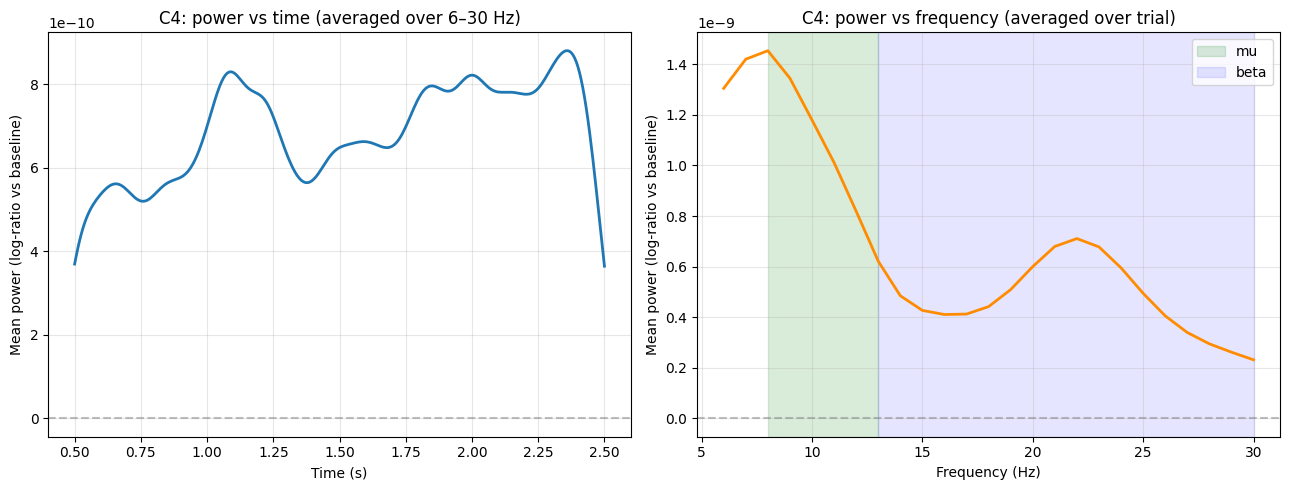

In [16]:
# Collapse the C4 time-frequency map into two 1D views


# Get the TFR data for C4: shape is (n_channels, n_freqs, n_times)
ch_idx = tfr_left.ch_names.index('C4')
power = tfr_left.data[ch_idx]          # shape: (n_freqs, n_times)
times = tfr_left.times
freqs = tfr_left.freqs

# Wave 1: average over FREQUENCY -> power vs time
power_vs_time = power.mean(axis=0)     # collapse freq axis

# Wave 2: average over TIME -> power vs frequency
power_vs_freq = power.mean(axis=1)     # collapse time axis

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(times, power_vs_time, linewidth=2)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Mean power (log-ratio vs baseline)')
ax1.set_title('C4: power vs time (averaged over 6–30 Hz)')
ax1.grid(True, alpha=0.3)

ax2.plot(freqs, power_vs_freq, linewidth=2, color='darkorange')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvspan(8, 13, alpha=0.15, color='green', label='mu')
ax2.axvspan(13, 30, alpha=0.10, color='blue', label='beta')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Mean power (log-ratio vs baseline)')
ax2.set_title('C4: power vs frequency (averaged over trial)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

No baseline correction applied


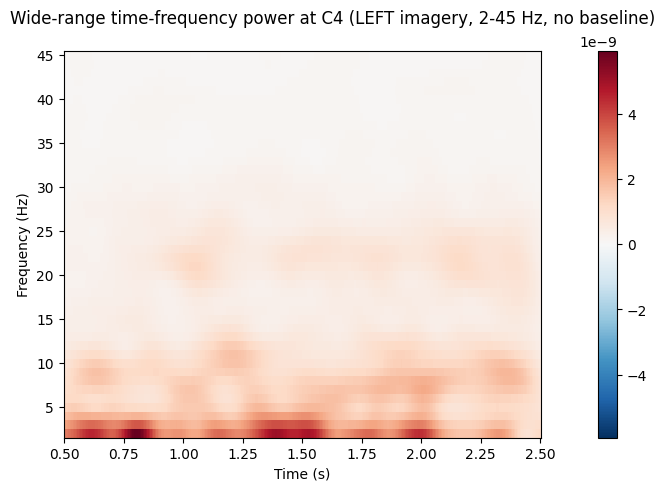

[<Figure size 640x480 with 2 Axes>]

In [17]:
# Option A: widen the TFR analysis range to 2-45 Hz (data untouched — just looking wider)
freqs_wide = np.arange(2, 46, 1)        # 2,3,...,45 Hz
n_cycles_wide = freqs_wide / 2.0

tfr_left_wide = epochs['T1'].compute_tfr(
    method='morlet',
    freqs=freqs_wide,
    n_cycles=n_cycles_wide,
    return_itc=False,
    average=True,
    picks=['C3', 'C4'],
)

# Heatmap at C4 — NOTE: no baseline this time, so we see RAW power distribution
tfr_left_wide.plot(
    picks=['C4'],
    title='Wide-range time-frequency power at C4 (LEFT imagery, 2-45 Hz, no baseline)',
)

In [18]:
# Re-epoch with a PRE-CUE baseline period for proper ERD/ERS analysis
# Window: -1.0s (before cue, true rest) to +3.0s (after cue, through imagery)
tmin_tfr, tmax_tfr = -1.0, 3.0

epochs_tfr = mne.Epochs(
    raw_mi, events,                 # broadband raw_mi (NOT filtered) for TFR
    event_id=epoch_event_id,
    tmin=tmin_tfr, tmax=tmax_tfr,
    baseline=None,                  # don't baseline-correct the time series; we do it in the TFR step
    picks='eeg', preload=True,
)

print(epochs_tfr)
print("New TFR-epoch shape:", epochs_tfr.get_data().shape)

Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 45 events and 641 original time points ...
0 bad epochs dropped
<Epochs | 45 events (all good), -1 – 3 s (baseline off), ~14.2 MiB, data loaded,
 'T1': 23
 'T2': 22>
New TFR-epoch shape: (45, 64, 641)


Applying baseline correction (mode: logratio)


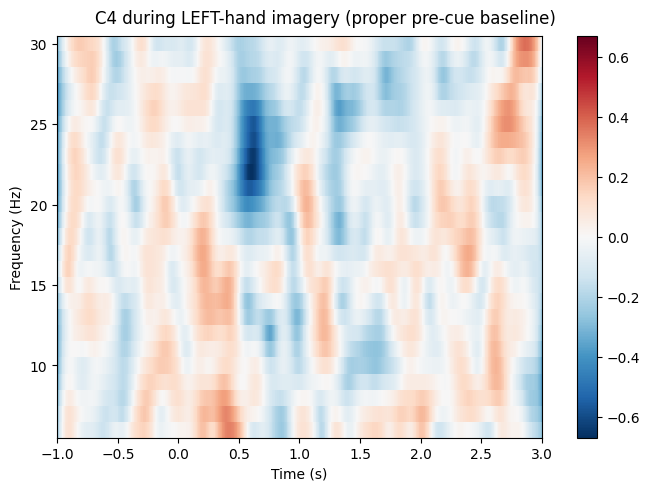

[<Figure size 640x480 with 2 Axes>]

In [19]:
# Recompute the TFR on the new epochs (with pre-cue rest), at C3 and C4
freqs_tfr = np.arange(6, 31, 1)         # back to 6-30 Hz: focus on mu + beta
n_cycles = freqs_tfr / 2.0

tfr_left = epochs_tfr['T1'].compute_tfr(   # T1 = imagined LEFT hand
    method='morlet',
    freqs=freqs_tfr,
    n_cycles=n_cycles,
    return_itc=False,
    average=True,
    picks=['C3', 'C4'],
)

# Plot C4 with a PROPER pre-cue baseline: -1.0s to 0s (true rest, before the cue)
tfr_left.plot(
    picks=['C4'],
    baseline=(-1.0, 0.0),       # genuine rest period now
    mode='logratio',
    title='C4 during LEFT-hand imagery (proper pre-cue baseline)',
)

Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)


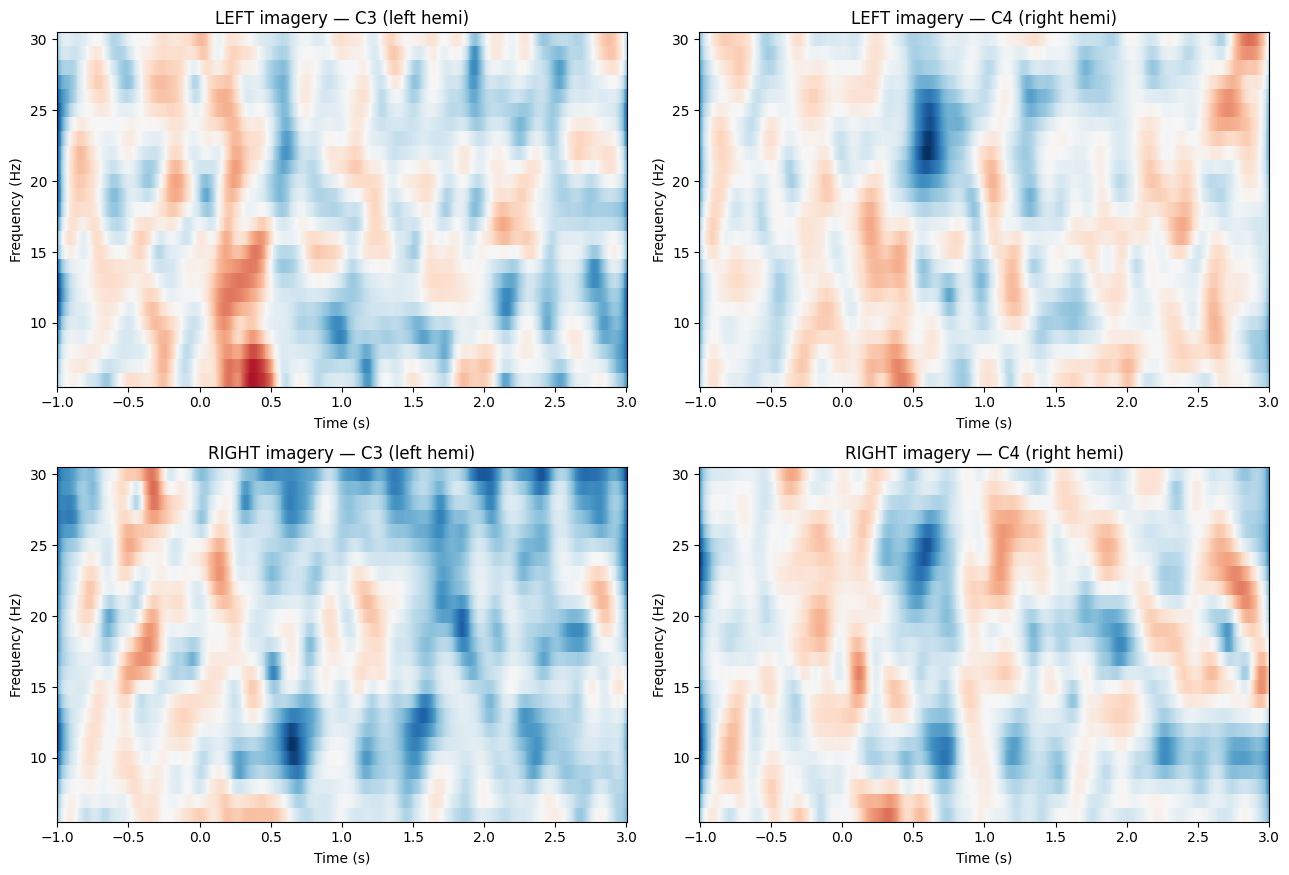

In [20]:
# Compute TFR for RIGHT-hand imagery as well
tfr_right = epochs_tfr['T2'].compute_tfr(
    method='morlet',
    freqs=freqs_tfr,
    n_cycles=n_cycles,
    return_itc=False,
    average=True,
    picks=['C3', 'C4'],
)

# 2x2 grid: rows = condition (left/right imagery), cols = channel (C3/C4)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

tfr_left.plot(picks=['C3'], baseline=(-1.0, 0.0), mode='logratio',
              axes=axes[0, 0], show=False, colorbar=False)
axes[0, 0].set_title('LEFT imagery — C3 (left hemi)')

tfr_left.plot(picks=['C4'], baseline=(-1.0, 0.0), mode='logratio',
              axes=axes[0, 1], show=False, colorbar=False)
axes[0, 1].set_title('LEFT imagery — C4 (right hemi)')

tfr_right.plot(picks=['C3'], baseline=(-1.0, 0.0), mode='logratio',
               axes=axes[1, 0], show=False, colorbar=False)
axes[1, 0].set_title('RIGHT imagery — C3 (left hemi)')

tfr_right.plot(picks=['C4'], baseline=(-1.0, 0.0), mode='logratio',
               axes=axes[1, 1], show=False, colorbar=False)
axes[1, 1].set_title('RIGHT imagery — C4 (right hemi)')

plt.tight_layout()
plt.show()

## 4. Motor Imagery Classification: CSP + LDA

Having explored and cleaned the data, the next phase builds an actual
classifier that predicts **left vs. right hand imagery** from a single trial.

### Pipeline overview

The baseline pipeline has three stages:

1. **Filtered epochs (8–30 Hz):** we classify on band-limited data so the
   model sees only the mu (8–13 Hz) and beta (13–30 Hz) motor rhythms.
2. **CSP (Common Spatial Patterns):** feature extraction via spatial filtering.
3. **LDA (Linear Discriminant Analysis):** a simple, robust linear classifier.

Accuracy is measured with **cross-validation** (training on some trials and
testing on held-out trials) so the reported number is an honest estimate of
how the model generalizes to unseen data.

### What CSP does

CSP is a spatial filter that finds the **weighted combinations of electrodes**
that best separate the two classes — rather than relying on any single channel
(like raw C3 or C4), which we saw is noisy and only partially lateralized.

The method is built on **covariance matrices**. For each trial, the channel
covariance matrix captures the spatial power structure of the signal (in
band-limited data, **variance = band power**). CSP averages these covariances
within each class (left, right), then solves an **optimization problem**: it
finds spatial filters that **maximize the variance (power) for one class while
minimizing it for the other**. Because it optimizes both directions at once,
the resulting filters are tuned to the *difference* between the hemispheres.

This directly targets the neuroscience: motor imagery produces
**event-related desynchronization (ERD)** — a power drop — over the
**contralateral** motor cortex, and often **event-related synchronization
(ERS)** — a power rise — elsewhere. Left-hand imagery desynchronizes the right
hemisphere (C4); right-hand imagery desynchronizes the left hemisphere (C3).
CSP learns the spatial filters that best capture this lateralized power
difference, pulling the signal out of the 64-channel mixture where it is
otherwise smeared and hard to see.

Concretely, CSP:
- computes and averages per-class channel covariance matrices,
- whitens against their sum so the two classes' variances become
  complementary (each direction's per-class eigenvalues sum to 1),
- keeps the spatial filters with the most extreme eigenvalues (best for one
  class, worst for the other),
- and turns each trial into a small set of **log-variance features** that
  encode left vs. right, which LDA then classifies.

A useful bonus: each CSP filter can be plotted as a **scalp map**, and for
motor imagery these should highlight the motor cortices — a visual check that
CSP rediscovered the relevant physiology directly from data.

### Later: spatial preprocessing experiments (CAR / Laplacian)

After establishing the CSP+LDA **baseline**, we will test whether adding a
fixed **spatial re-referencing** step improves accuracy:

- **CAR (Common Average Reference):** subtracts the average of all channels
  from each channel, removing globally-shared noise and reference artifacts.
- **Large Laplacian:** re-references each channel against a ring of surrounding
  electrodes, sharpening local spatial focus.

These are *spatial* operations, so the correct pipeline order is
**spatial re-reference → bandpass filter → epoch → CSP**. Each variant will be
evaluated against the baseline with the same cross-validation, so any
improvement is measured rather than assumed. (Note: CAR and Laplacian both
require many electrodes, so they may not transfer to a minimal 2-channel
hardware setup — a distinction worth reporting.)

### Evaluation: cross-validation (and why CSP must be inside it)

**Both CSP and LDA are trained models.** CSP is not a fixed filter — it *learns*
its spatial filters from the covariance structure of the training trials, just as
LDA learns its decision boundary. Both have parameters fit to data.

**Why cross-validation.** Testing a model on the same data it trained on gives a
falsely optimistic score — the model has already seen those trials. To estimate
how well it generalizes to *unseen* trials (the only thing that matters for a real
BCI), we hold out test trials the model never saw during training. With only 45
trials, a single split is noisy, so we repeat the split multiple times and average,
giving a stable, honest accuracy estimate.

**The critical rule — no data leakage.** Because CSP is trained, it must only ever
see training trials, never test trials, *within each split*. If CSP were fit on all
trials before validation, it would have "seen" the test trials while learning its
filters, inflating the score. To prevent this, CSP and LDA are wrapped in a single
**Pipeline**: in every cross-validation fold, both are re-fit on that fold's training
trials only, then applied to its held-out test trials. This guarantees the test data
stays truly unseen.

**Scheme used.** Stratified K-Fold (K=5): the trials are split into 5 balanced folds;
each fold serves as the test set once while the model trains on the other four.
Every trial is tested exactly once, using the limited data efficiently while
preserving the left/right class balance in each fold.

**A stricter future test.** These trials come from three concatenated runs, and
standard cross-validation shuffles trials across runs. A tougher, more realistic
evaluation holds out *entire runs* (e.g. train on runs 4 and 8, test on run 12) to
verify the model generalizes across separate recordings — closer to real deployment.

In [21]:
# CSP+LDA BASELINE — Step 1 (reuse already-filtered epochs)
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from mne.decoding import CSP
import numpy as np

# Reuse the filtered epochs from the filtering step (8-30 Hz, 0.5-2.5s window)
X = epochs_filt.get_data(copy=False)      # (n_trials, n_channels, n_times)
y = epochs_filt.events[:, -1]             # labels (T1 vs T2)

print("X shape (trials, channels, samples):", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y), "counts:", np.bincount(y)[np.unique(y)])

X shape (trials, channels, samples): (45, 64, 321)
y shape: (45,)
Unique labels: [2 3] counts: [23 22]


In [22]:
# --- Build the pipeline: CSP feature extraction -> LDA classifier ---
csp = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis()
clf = Pipeline([('CSP', csp), ('LDA', lda)])

# --- Cross-validation scheme ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- (Optional) peek: see which trial indices are train vs test in each fold ---
print("Fold assignments (trial indices):")
for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    print(f"  Fold {i+1}: {len(train_idx)} train, {len(test_idx)} test "
          f"| test trials = {test_idx}")

# --- Run cross-validation: fits CSP+LDA on train, scores on test, per fold ---
scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

print("\nPer-fold accuracy:", np.round(scores, 3))
print(f"Mean accuracy: {scores.mean():.3f}  (+/- {scores.std():.3f})")
print(f"Chance level: {max(np.bincount(y)) / len(y):.3f}")

Fold assignments (trial indices):
  Fold 1: 36 train, 9 test | test trials = [ 3  4  6 13 17 20 23 26 27]
  Fold 2: 36 train, 9 test | test trials = [ 2  5  7 10 12 18 19 36 44]
  Fold 3: 36 train, 9 test | test trials = [ 8 11 15 16 22 37 39 41 43]
  Fold 4: 36 train, 9 test | test trials = [ 0  9 14 29 30 31 32 34 38]
  Fold 5: 36 train, 9 test | test trials = [ 1 21 24 25 28 33 35 40 42]
Computing rank from data with rank=None


    Using tolerance 0.0001 (2.2e-16 eps * 64 dim * 7.2e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 9.9e-05 (2.2e-16 eps * 64 dim * 7e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.0001 (2.2e-16 eps * 64 dim * 7.1e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 co

Computing rank from data with rank=None
    Using tolerance 0.00011 (2.2e-16 eps * 64 dim * 7.9e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


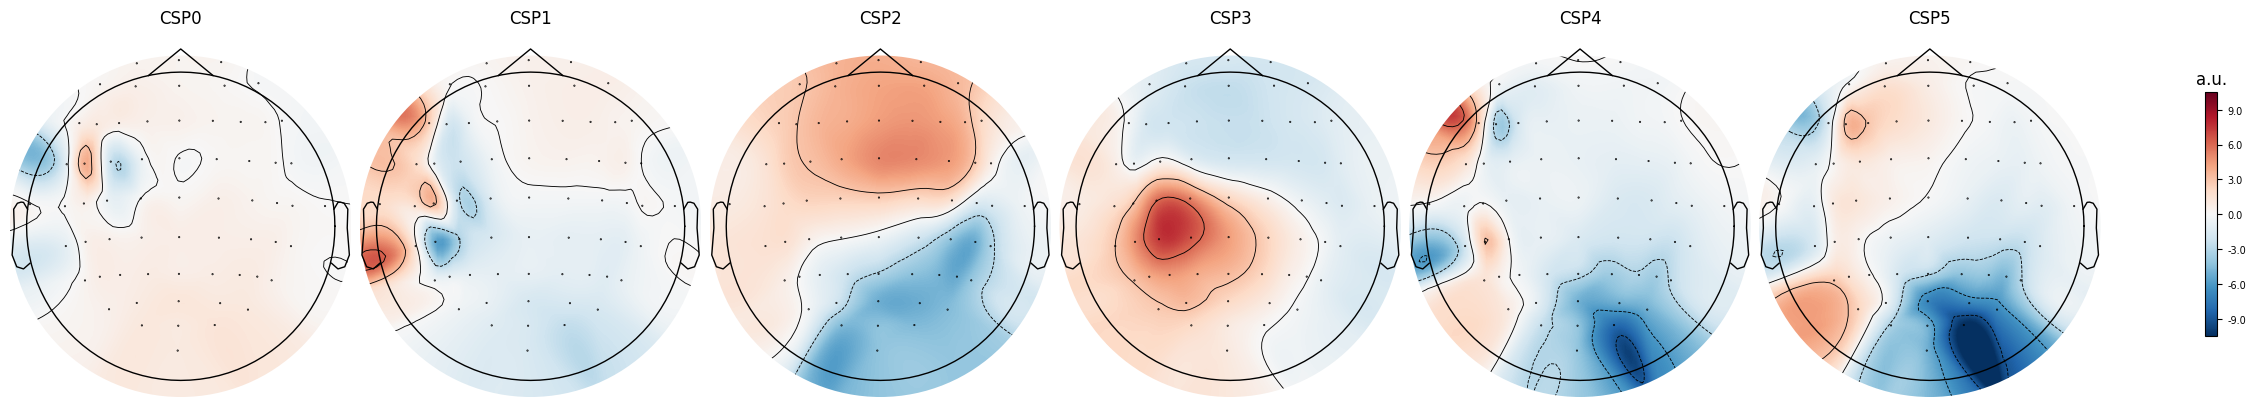

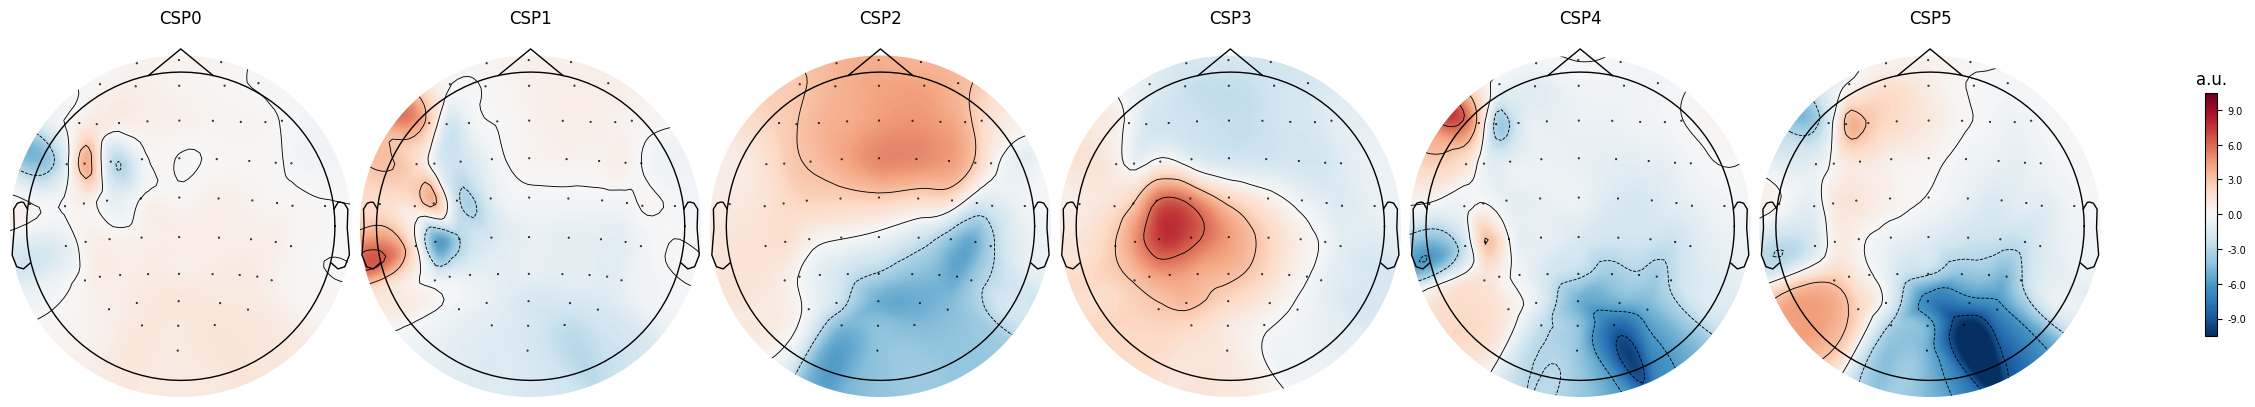

In [23]:
# Visualize the CSP spatial patterns as scalp maps
# Fit CSP on all data just for visualization (not for scoring)
csp_viz = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
csp_viz.fit(X, y)

# Plot the CSP patterns as topographic scalp maps
csp_viz.plot_patterns(
    epochs_filt.info,
    components=[0, 1, 2, 3, 4, 5],   # just the 6 we use
    ch_type='eeg',
    units='a.u.',
    size=2.5,                         # bigger heads
)

Computing rank from data with rank=None
    Using tolerance 0.0001 (2.2e-16 eps * 64 dim * 7.2e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 9.9e-05 (2.2e-16 eps * 64 dim * 7e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.0001 (2.2e-16 eps * 64 dim * 7.1e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRIC

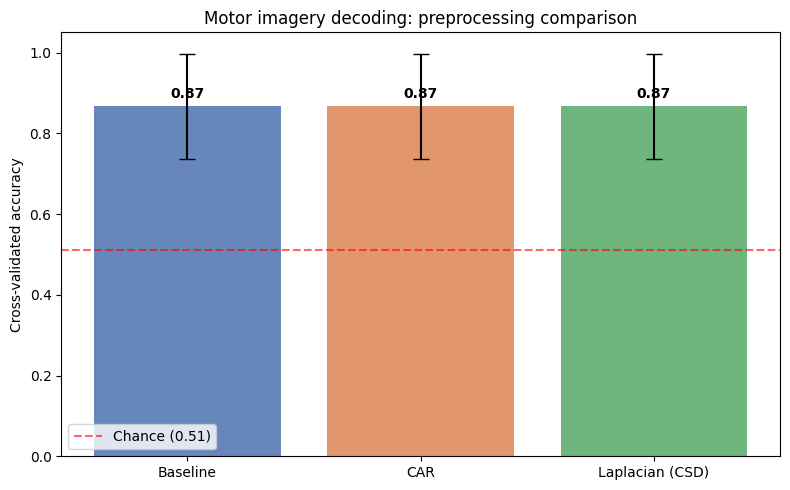

In [24]:
# EXPERIMENT: baseline vs CAR vs Laplacian (CSD), all evaluated identically
from mne.preprocessing import compute_current_source_density

def build_epochs(raw_source, spatial=None):
    """Apply an optional spatial filter, then notch+bandpass, then epoch."""
    r = raw_source.copy()
    if spatial == 'car':
        r.set_eeg_reference('average', verbose=False)
    r.notch_filter(60.0, picks='eeg', verbose=False)
    r.filter(8.0, 30.0, picks='eeg', verbose=False)
    ep = mne.Epochs(r, events, event_id=epoch_event_id,
                    tmin=0.5, tmax=2.5, baseline=None,
                    picks='eeg', preload=True, verbose=False)
    if spatial == 'laplacian':
        ep = compute_current_source_density(ep, verbose=False)
    return ep

# Build the three datasets
ep_base = build_epochs(raw_mi, spatial=None)
ep_car  = build_epochs(raw_mi, spatial='car')
ep_lap  = build_epochs(raw_mi, spatial='laplacian')

# Shared evaluation function
def evaluate(ep):
    Xe = ep.get_data(copy=False)
    ye = ep.events[:, -1]
    pipe = Pipeline([('CSP', CSP(n_components=6, reg=None, log=True, norm_trace=False)),
                     ('LDA', LinearDiscriminantAnalysis())])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(pipe, Xe, ye, cv=cv, scoring='accuracy')

results = {
    'Baseline':  evaluate(ep_base),
    'CAR':       evaluate(ep_car),
    'Laplacian (CSD)': evaluate(ep_lap),
}

# Report
print("Cross-validated accuracy by preprocessing:")
for name, sc in results.items():
    print(f"  {name:16s}: mean={sc.mean():.3f}  std={sc.std():.3f}  folds={np.round(sc,2)}")

# Side-by-side bar chart with error bars
fig, ax = plt.subplots(figsize=(8, 5))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds  = [results[n].std() for n in names]
bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=['#4C72B0', '#DD8452', '#55A868'], alpha=0.85)
ax.axhline(0.511, color='red', linestyle='--', alpha=0.6, label='Chance (0.51)')
ax.set_ylabel('Cross-validated accuracy')
ax.set_title('Motor imagery decoding: preprocessing comparison')
ax.set_ylim(0, 1.05)
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.02, f'{m:.2f}', ha='center', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Making sure the data above is correct and its not an issue with the data being proccessed incorrectly 

In [25]:
import numpy as np

# Are the three datasets actually different?
Xb = ep_base.get_data(copy=False)
Xc = ep_car.get_data(copy=False)
Xl = ep_lap.get_data(copy=False)

print("base vs car identical? ", np.allclose(Xb, Xc))
print("base vs lap identical? ", np.allclose(Xb, Xl))
print("base shape:", Xb.shape, "| car shape:", Xc.shape, "| lap shape:", Xl.shape)
print("base rank-ish (channel count):", Xb.shape[1])

base vs car identical?  False
base vs lap identical?  False
base shape: (45, 64, 321) | car shape: (45, 64, 321) | lap shape: (45, 64, 321)
base rank-ish (channel count): 64


In [26]:
# Self-contained: define, build, evaluate — no stale-variable risk
from mne.preprocessing import compute_current_source_density

def build_epochs(spatial=None):
    r = raw_mi.copy()   # always start fresh from raw_mi
    if spatial == 'car':
        r.set_eeg_reference('average', projection=False, verbose=False)
    r.notch_filter(60.0, picks='eeg', verbose=False)
    r.filter(8.0, 30.0, picks='eeg', verbose=False)
    ep = mne.Epochs(r, events, event_id=epoch_event_id,
                    tmin=0.5, tmax=2.5, baseline=None,
                    picks='eeg', preload=True, verbose=False)
    if spatial == 'laplacian':
        ep = compute_current_source_density(ep, verbose=False)
    return ep

def evaluate(ep):
    Xe = ep.get_data(copy=False)
    ye = ep.events[:, -1]
    pipe = Pipeline([('CSP', CSP(n_components=6, reg=None, log=True, norm_trace=False)),
                     ('LDA', LinearDiscriminantAnalysis())])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(pipe, Xe, ye, cv=cv, scoring='accuracy')

ep_base = build_epochs(None)
ep_car  = build_epochs('car')
ep_lap  = build_epochs('laplacian')

# Confirm they differ
print("base vs car identical?", np.allclose(ep_base.get_data(), ep_car.get_data()))
print("base vs lap identical?", np.allclose(ep_base.get_data(), ep_lap.get_data()))

for name, ep in [('Baseline', ep_base), ('CAR', ep_car), ('Laplacian', ep_lap)]:
    sc = evaluate(ep)
    print(f"{name:12s}: mean={sc.mean():.3f}  folds={np.round(sc,2)}")

base vs car identical? False
base vs lap identical? False
Computing rank from data with rank=None
    Using tolerance 0.0001 (2.2e-16 eps * 64 dim * 7.2e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 9.9e-05 (2.2e-16 eps * 64 dim * 7e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.0001 (2.2e-16 eps * 64 dim * 7.1e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank

In [27]:
from sklearn.model_selection import cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def preds(ep):
    Xe = ep.get_data(copy=False); ye = ep.events[:, -1]
    pipe = Pipeline([('CSP', CSP(n_components=6, reg=None, log=True, norm_trace=False)),
                     ('LDA', LinearDiscriminantAnalysis())])
    return cross_val_predict(pipe, Xe, ye, cv=cv)

p_base = preds(ep_base)
p_car  = preds(ep_car)
p_lap  = preds(ep_lap)

print("base vs car  predictions identical?", np.array_equal(p_base, p_car))
print("base vs lap  predictions identical?", np.array_equal(p_base, p_lap))
print("base preds:", p_base)
print("lap  preds:", p_lap)

Computing rank from data with rank=None
    Using tolerance 0.0001 (2.2e-16 eps * 64 dim * 7.2e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 9.9e-05 (2.2e-16 eps * 64 dim * 7e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.0001 (2.2e-16 eps * 64 dim * 7.1e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRIC

In [28]:
from sklearn.model_selection import cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def preds(ep):
    Xe = ep.get_data(copy=False); ye = ep.events[:, -1]
    pipe = Pipeline([('CSP', CSP(n_components=6, reg=None, log=True, norm_trace=False)),
                     ('LDA', LinearDiscriminantAnalysis())])
    return cross_val_predict(pipe, Xe, ye, cv=cv)

p_base = preds(ep_base)
p_car  = preds(ep_car)
p_lap  = preds(ep_lap)

print("base vs car  predictions identical?", np.array_equal(p_base, p_car))
print("base vs lap  predictions identical?", np.array_equal(p_base, p_lap))
print("base preds:", p_base)
print("lap  preds:", p_lap)

Computing rank from data with rank=None


    Using tolerance 0.0001 (2.2e-16 eps * 64 dim * 7.2e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 9.9e-05 (2.2e-16 eps * 64 dim * 7e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.0001 (2.2e-16 eps * 64 dim * 7.1e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance u

In [29]:
# Fit CSP on each dataset and compare the actual extracted features
def csp_features(ep):
    Xe = ep.get_data(copy=False); ye = ep.events[:, -1]
    c = CSP(n_components=6, reg=None, log=True, norm_trace=False)
    return c.fit_transform(Xe, ye)   # the log-variance features fed to LDA

f_base = csp_features(ep_base)
f_car  = csp_features(ep_car)
f_lap  = csp_features(ep_lap)

print("base vs car features identical?", np.allclose(f_base, f_car))
print("base vs lap features identical?", np.allclose(f_base, f_lap))
print("\nbase features [first trial]:", np.round(f_base[0], 3))
print("car  features [first trial]:", np.round(f_car[0], 3))
print("lap  features [first trial]:", np.round(f_lap[0], 3))

Computing rank from data with rank=None
    Using tolerance 0.00011 (2.2e-16 eps * 64 dim * 7.9e+09  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 7.7e-05 (2.2e-16 eps * 64 dim * 5.4e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 0.047 (2.2e-16 eps * 64 dim * 3.3e+12  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed 

## Testing the csp pipeline on multiple subjects to understand better the consistency of model across patients

In [30]:
# Multi-subject comparison: run the same CSP+LDA pipeline on several subjects
def evaluate_subject(subj, runs=(4, 8, 12)):
    """Download, filter, epoch, and CV-evaluate CSP+LDA for one subject."""
    fnames = eegbci.load_data(subjects=[subj], runs=list(runs),
                              path=str(data_dir), verbose=False)
    raws = [mne.io.read_raw_edf(f, preload=True, verbose=False) for f in fnames]
    raw = mne.concatenate_raws(raws, verbose=False)
    eegbci.standardize(raw)
    raw.set_montage(montage, verbose=False)

    raw.notch_filter(60.0, picks='eeg', verbose=False)
    raw.filter(8.0, 30.0, picks='eeg', verbose=False)

    evs, ev_id = mne.events_from_annotations(raw, verbose=False)
    ep = mne.Epochs(raw, evs,
                    event_id={'T1': ev_id['T1'], 'T2': ev_id['T2']},
                    tmin=0.5, tmax=2.5, baseline=None,
                    picks='eeg', preload=True, verbose=False)

    Xs = ep.get_data(copy=False)
    ys = ep.events[:, -1]

    pipe = Pipeline([('CSP', CSP(n_components=6, reg=None, log=True, norm_trace=False)),
                     ('LDA', LinearDiscriminantAnalysis())])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, Xs, ys, cv=cv, scoring='accuracy')
    chance = max(np.bincount(ys)) / len(ys)
    return scores.mean(), scores.std(), chance, len(ys)

# Test several subjects
subjects_to_test = [1, 2, 3, 4, 5]
print(f"{'Subject':>8} {'Mean Acc':>9} {'Std':>7} {'Chance':>8} {'Trials':>7}")
print("-" * 45)
subject_results = {}
for s in subjects_to_test:
    try:
        m, sd, ch, n = evaluate_subject(s)
        subject_results[s] = m
        print("subject")
        print(f"{s:>8} {m:>9.3f} {sd:>7.3f} {ch:>8.3f} {n:>7}")
    except Exception as e:
        print(f"{s:>8}  FAILED: {type(e).__name__}: {str(e)[:40]}")

 Subject  Mean Acc     Std   Chance  Trials
---------------------------------------------
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels 

Computing rank from data with rank=None


    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covarian

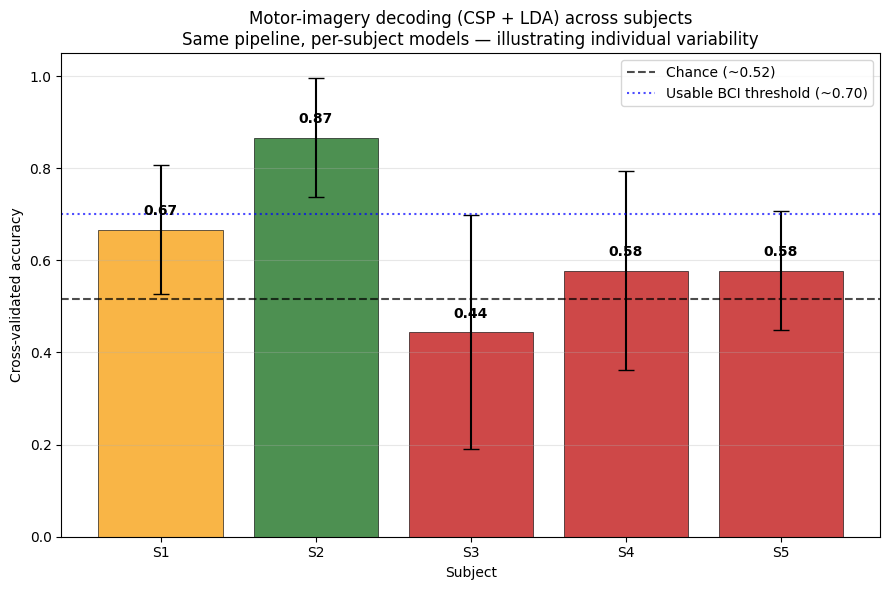

In [32]:
# Bar chart: motor-imagery decoding accuracy across subjects
# Rebuild the full stats so we can show error bars too
subjects_to_test = [1, 2, 3, 4, 5]
means, stds, chances = [], [], []
for s in subjects_to_test:
    m, sd, ch, n = evaluate_subject(s)
    means.append(m); stds.append(sd); chances.append(ch)

fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(subjects_to_test))
# Color bars by performance tier for quick visual reading
colors = []
for m in means:
    if m >= 0.75:      colors.append('#2E7D32')   # strong (green)
    elif m >= 0.60:    colors.append('#F9A825')   # moderate (amber)
    else:              colors.append('#C62828')   # weak / at-chance (red)

bars = ax.bar(x, means, yerr=stds, capsize=6, color=colors, alpha=0.85,
              edgecolor='black', linewidth=0.5)

# Chance line (use the typical ~0.51; they're all ~0.51-0.53)
ax.axhline(np.mean(chances), color='black', linestyle='--', alpha=0.7,
           label=f'Chance (~{np.mean(chances):.2f})')
ax.axhline(0.70, color='blue', linestyle=':', alpha=0.7,
           label='Usable BCI threshold (~0.70)')

# Value labels on top of each bar
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.025, f'{m:.2f}',
            ha='center', va='bottom', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'S{s}' for s in subjects_to_test])
ax.set_xlabel('Subject')
ax.set_ylabel('Cross-validated accuracy')
ax.set_title('Motor-imagery decoding (CSP + LDA) across subjects\n'
             'Same pipeline, per-subject models — illustrating individual variability')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()